In [7]:
# ================================================
# Forensic Scanner 3D CNN + Grad-CAM on Vast.ai
# Unlimited runtime | High TFLOPs
# ================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

print("✅ Environment loaded")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

✅ Environment loaded
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.5 GB
🚀 Using device: cuda


In [8]:
# ================================================
# VolumetricForensicCNN - 3D spatial-spectral classifier
# ================================================

class VolumetricForensicCNN(nn.Module):
    def __init__(self, in_channels, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv3d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm3d(64)
        self.pool1 = nn.MaxPool3d(2, stride=2)

        self.conv2 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm3d(128)
        self.pool2 = nn.MaxPool3d(2, stride=2)

        self.conv3 = nn.Conv3d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm3d(256)
        self.pool3 = nn.MaxPool3d(2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool3d((2, 2, 2))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2 * 2, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.adaptive_pool(x)
        return self.fc(x)

In [11]:
# ================================================
# FIXED VolumetricGradCAM - 3D XAI Heatmap
# ================================================

class VolumetricGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()          # shape: (B, C, D, H, W)

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()    # shape: (B, C, D, H, W)

    def generate_heatmap(self, input_tensor, target_class=1):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # 1. Forward pass
        output = self.model(input_tensor)

        # 2. Backprop only on target class score
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward(retain_graph=True)

        # 3. Global Average Pooling over spatial dimensions → per-channel weights
        # gradients shape: (1, 256, D, H, W) → pooled: (1, 256)
        pooled_grad = torch.mean(self.gradients, dim=(2, 3, 4)).squeeze(0)

        # 4. Weight the activations (remove batch dim)
        activations = self.activations[0]                    # (256, D, H, W)
        for i in range(activations.shape[0]):                # loop over channels
            activations[i] *= pooled_grad[i]                 # scalar broadcast

        # 5. Sum channels → single 3D heatmap
        heatmap = torch.sum(activations, dim=0).cpu().numpy()

        # 6. ReLU + normalize
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8)

        return heatmap

In [26]:
# ================================================
# FIXED VolumetricGradCAM - 3D XAI Heatmap
# ================================================

class VolumetricGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()          # shape: (B, C, D, H, W)

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()    # shape: (B, C, D, H, W)

    def generate_heatmap(self, input_tensor, target_class=1):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # 1. Forward pass
        output = self.model(input_tensor)

        # 2. Backprop only on target class score
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward(retain_graph=True)

        # 3. Global Average Pooling over spatial dimensions → per-channel weights
        # gradients shape: (1, 256, D, H, W) → pooled: (1, 256)
        pooled_grad = torch.mean(self.gradients, dim=(2, 3, 4)).squeeze(0)

        # 4. Weight the activations (remove batch dim)
        activations = self.activations[0]                    # (256, D, H, W)
        for i in range(activations.shape[0]):                # loop over channels
            activations[i] *= pooled_grad[i]                 # scalar broadcast

        # 5. Sum channels → single 3D heatmap
        heatmap = torch.sum(activations, dim=0).cpu().numpy()

        # 6. ReLU + normalize
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8)

        return heatmap

In [27]:
# Quick sanity check with your tatp.npz
sample = np.load("tatp.npz")['flux']                    # (nx, ny, nz, n_neutron, n_photon)
C = sample.shape[3] * sample.shape[4]
sample = sample.reshape(*sample.shape[:3], C).transpose(3, 0, 1, 2)   # (C, D, H, W)

x = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).to(device)

model = VolumetricForensicCNN(in_channels=C, num_classes=2).to(device)
print("✅ Model loaded, input shape:", x.shape)

# Run inference + Grad-CAM
logits = model(x)
cam = VolumetricGradCAM(model, model.conv3)
heatmap = cam.generate_heatmap(x, target_class=1)

print(f"✅ 3D Heatmap generated → shape {heatmap.shape}")

✅ Model loaded, input shape: torch.Size([1, 1400, 40, 40, 20])
✅ 3D Heatmap generated → shape (10, 10, 5)


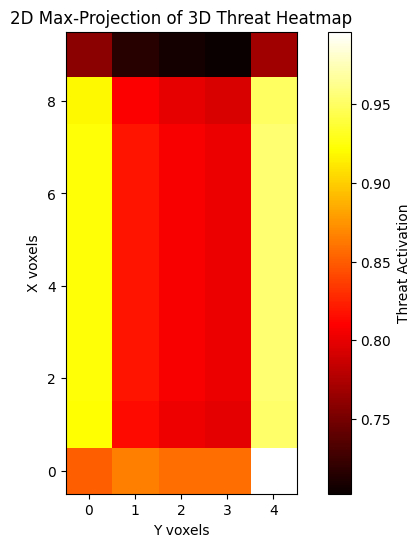

✅ Upsampled heatmap shape: (40, 40, 20)
✅ Saved as threat_heatmap_3d.npy


In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Quick 2D max-projection (easy to see)
heatmap_max = np.max(heatmap, axis=0)           # max over depth
plt.figure(figsize=(8,6))
plt.imshow(heatmap_max, cmap='hot', origin='lower')
plt.colorbar(label='Threat Activation')
plt.title('2D Max-Projection of 3D Threat Heatmap')
plt.xlabel('Y voxels')
plt.ylabel('X voxels')
plt.show()

# 2. Upsample back to original OpenMC mesh resolution
# Assuming your original mesh was e.g. 40×40×20 before pooling → adjust if different
original_shape = (40, 40, 20)                   # change to your real (nx, ny, nz)

zoom_factors = (
    original_shape[0] / heatmap.shape[0],
    original_shape[1] / heatmap.shape[1],
    original_shape[2] / heatmap.shape[2]
)

high_res_heatmap = zoom(heatmap, zoom_factors, order=1)   # trilinear

print(f"✅ Upsampled heatmap shape: {high_res_heatmap.shape}")

# Save for ParaView / later analysis
np.save("threat_heatmap_3d.npy", high_res_heatmap)
print("✅ Saved as threat_heatmap_3d.npy")

In [30]:
# ================================================
# Load one of your Layered 5D files + run 3D CNN + Grad-CAM
# ================================================

# Choose the file that showed the clear glow (you said 5 MeV NQ looks good)
file_path = "5mev_nq.npz"     # ← change this line if you want another one

data = np.load(file_path)
flux = data['flux']                                   # shape should be (nx, ny, nz, n_neutron_bins, n_photon_bins)

print(f"Loaded {file_path}")
print(f"Original shape: {flux.shape}")

# These layered files usually have only 1 neutron bin per file → flatten neutron + photon
nx, ny, nz, n_neutron, n_photon = flux.shape
C = n_neutron * n_photon                              # total spectral channels

# Reshape to PyTorch Conv3D format: (C, D, H, W)
sample = flux.reshape(nx, ny, nz, C).transpose(3, 0, 1, 2)

x = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).to(device)

print(f"Final tensor shape for model: {x.shape}")

Loaded 5mev_nq.npz
Original shape: (40, 40, 20, 140)


ValueError: not enough values to unpack (expected 5, got 4)

In [31]:
# ================================================
# Smart loader for Layered 5D / 4D files
# ================================================

file_path = "5mev_nq.npz"          # ← change this to whichever file you want to test

data = np.load(file_path)
flux = data['flux']

print(f"Loaded {file_path}")
print(f"Original shape: {flux.shape}")

# Auto-detect shape
if len(flux.shape) == 5:
    # Old full format: (nx, ny, nz, n_neutron, n_photon)
    nx, ny, nz, n_neutron, n_photon = flux.shape
    C = n_neutron * n_photon
    sample = flux.reshape(nx, ny, nz, C).transpose(3, 0, 1, 2)
    print("→ Detected 5D format → flattened spectral channels")
elif len(flux.shape) == 4:
    # New layered format: (nx, ny, nz, total_channels)
    nx, ny, nz, C = flux.shape
    sample = flux.transpose(3, 0, 1, 2)          # → (C, D, H, W)
    print("→ Detected 4D layered format (already flattened)")
else:
    raise ValueError(f"Unexpected shape: {flux.shape}")

x = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).to(device)

print(f"✅ Final tensor shape for model: {x.shape}")

Loaded 5mev_nq.npz
Original shape: (40, 40, 20, 140)
→ Detected 4D layered format (already flattened)
✅ Final tensor shape for model: torch.Size([1, 140, 40, 40, 20])


In [32]:
file_path = "5mev_nq.npz"   # change if you want another file

data = np.load(file_path)
flux = data['flux']

print(f"Loaded {file_path}")
print(f"Original shape: {flux.shape}")

# Auto-detect 4D layered format
nx, ny, nz, C = flux.shape
sample = flux.transpose(3, 0, 1, 2)   # (C, D, H, W)

x = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).to(device)
print(f"✅ Final tensor shape for model: {x.shape}")

Loaded 5mev_nq.npz
Original shape: (40, 40, 20, 140)
✅ Final tensor shape for model: torch.Size([1, 140, 40, 40, 20])


In [33]:
# Instantiate model (140 channels for this file)
model = VolumetricForensicCNN(in_channels=C, num_classes=2).to(device)

# Run inference + Grad-CAM
logits = model(x)
cam = VolumetricGradCAM(model, model.conv3)
heatmap = cam.generate_heatmap(x, target_class=1)

print(f"✅ 3D Heatmap generated → shape {heatmap.shape}")

✅ 3D Heatmap generated → shape (10, 10, 5)


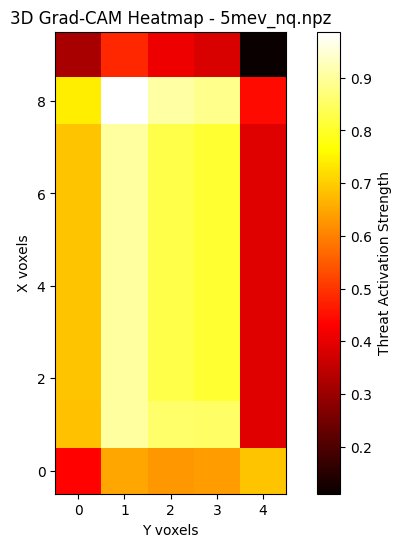

✅ Saved threat_heatmap_3d.npy


In [34]:
# Simple 2D max projection
import matplotlib.pyplot as plt

max_proj = np.max(heatmap, axis=0)   # collapse depth

plt.figure(figsize=(8, 6))
plt.imshow(max_proj, cmap='hot', origin='lower')
plt.colorbar(label='Threat Activation Strength')
plt.title(f'3D Grad-CAM Heatmap - {file_path}')
plt.xlabel('Y voxels')
plt.ylabel('X voxels')
plt.show()

# Save the full 3D heatmap
np.save("threat_heatmap_3d.npy", heatmap)
print("✅ Saved threat_heatmap_3d.npy")